In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import csv
from scipy.signal import butter, lfilter
import scipy.stats as sci

In [2]:
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y

In [3]:
def valMap(value, istart, istop, ostart, ostop):
        return ostart + (ostop - ostart) * ((value - istart) / (istop - istart))

In [51]:
version = "0_05"

### Trajectory

In [52]:
trajectory_filename = '/Users/tuengo/allostatic_ws/data/trajectory_data_v' + version + '.csv'
df_trajectory = pd.read_csv(trajectory_filename, nrows = 500000)

XPose = df_trajectory['XPosition'].to_list()
YPose = df_trajectory['YPosition'].to_list()

In [53]:
resource_filename = '/Users/tuengo/allostatic_ws/data/resource_data_v' + version + '.csv'
df_resource = pd.read_csv(resource_filename, nrows = 500000)

df_food = df_resource.loc[df_resource['Color'] == 'green']
XFood = df_food['XPosition'].to_list()
YFood = df_food['YPosition'].to_list()

df_water = df_resource.loc[df_resource['Color'] == 'blue']
XWater = df_water['XPosition'].to_list()
YWater = df_water['YPosition'].to_list()

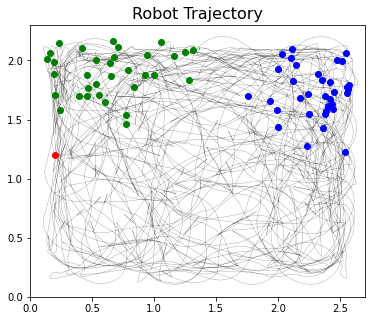

In [54]:
plt.figure(figsize=(6, 5))
plt.plot(XPose, YPose, linewidth=0.3, color='grey')
plt.title('Robot Trajectory', fontsize=16)
plt.plot(XPose[0],YPose[0],'ro')

for i in range(len(df_food)):
    if XFood[i] > 0.1 and YFood[i] < 2.2:
        plt.plot(XFood[i], YFood[i], 'o', linewidth=1, color='green')
for j in range(len(df_water)):
    if XWater[j] < 2.6 and YWater[j] < 2.2:
        plt.plot(XWater[j], YWater[j], 'o', linewidth=1, color='blue')
        
plt.xlim(0.0, 2.7)
plt.ylim(0.0, 2.3)
plt.show()

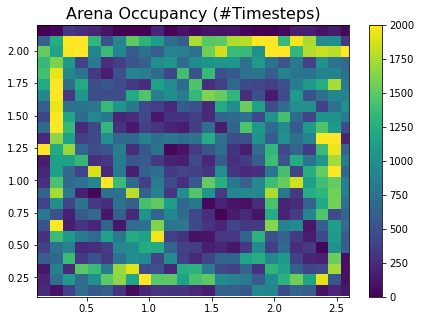

In [55]:
plt.figure(figsize=(7, 5))
plt.hist2d(XPose, YPose, bins=25, density=False, vmax=2000) 
plt.colorbar()
plt.title('Arena Occupancy (#Timesteps)', fontsize=16)
plt.xlim(0.1, 2.6)
plt.ylim(0.1, 2.2)
plt.show()

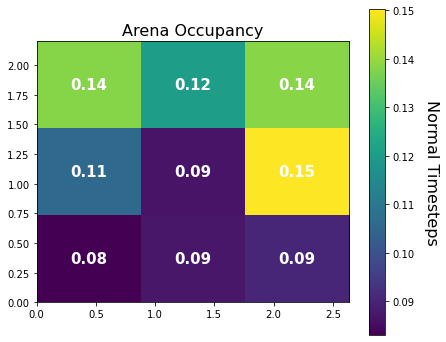

In [56]:
xy_array = np.column_stack((XPose, YPose))
x_array = xy_array[:,0]
y_array = xy_array[:,1]

bins = 3
xedges= []
yedges= []
for i in range(bins):
    xedges.append((max(XPose)/bins)*i)
    yedges.append((max(YPose)/bins)*i)
xedges.append((max(XPose)))
yedges.append((max(YPose)))

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_aspect("equal")
hist, xbins, ybins, im = ax.hist2d(x_array, y_array, bins=(xedges, yedges))
H = hist.T
H_normalized = H/float(xy_array.shape[0])

for i in range(len(ybins)-1):
    for j in range(len(xbins)-1):
        ax.text(xbins[j]+xedges[1]/2, ybins[i]+yedges[1]/2, round(H_normalized[i,j],2), fontsize=15, ha="center", va="center", color="w", fontweight="bold")      
        
ax.set_title('Arena Occupancy', fontsize=16)
hist = ax.imshow(H_normalized, origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]])
cbar = fig.colorbar(hist)
cbar.set_label('Normal Timesteps', rotation=270, fontsize=16, labelpad=+25)
plt.show()

### Homeostasis

#### Actual value aV

In [57]:
allo_filename = '/Users/tuengo/allostatic_ws/data/allostatic_data_v' + version + '.csv'
df_allo = pd.read_csv(allo_filename, nrows = 145000)

In [58]:
df_energy_aV = df_allo['aVEnergy']
df_energy_dV = df_allo['dVEnergy']
print(round(df_energy_aV.mean(),3), round(df_energy_aV.std(),3), round(df_energy_aV.min(),3))

stat_normal, p_normal = sci.normaltest(df_energy_aV)
print("Normality test p value = " + str(p_normal))

0.636 0.294 0.1
Normality test p value = 0.0


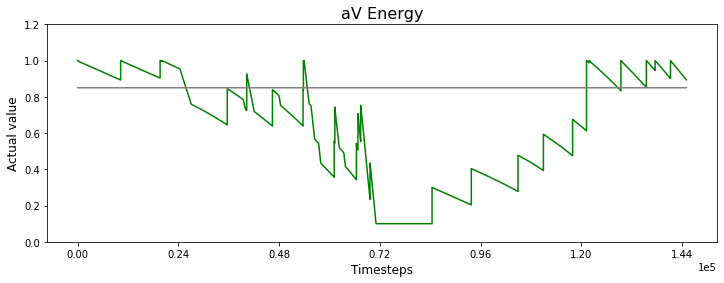

In [59]:
energy_steps = round(len(df_energy_aV)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_energy_aV,'green')
plt.plot(df_energy_dV,'grey')
plt.xticks(np.arange(0, len(df_energy_aV), step=energy_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.3, step=0.2))
plt.title('aV Energy', fontsize=16)
plt.ylabel('Actual value', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

In [60]:
top_bin_f=[]
mid_bin_f=[]
bot_bin_f=[]

for i in range(len(df_energy_aV)):
    if df_energy_aV[i] <= 1/3:
        bot_bin_f.append(df_energy_aV[i])
    if df_energy_aV[i] > 1/3 and df_energy_aV[i] < 2/3:
        mid_bin_f.append(df_energy_aV[i])
    if df_energy_aV[i] >= 2/3:
        top_bin_f.append(df_energy_aV[i])

if len(bot_bin_f) > 0:
    mean_bot_bin_f = round(sum(bot_bin_f)/len(bot_bin_f),3)
    print("Bot_bin mean value = " + str(mean_bot_bin_f))
if len(mid_bin_f) > 0:
    mean_mid_bin_f = round(sum(mid_bin_f)/len(mid_bin_f),3)
    print("Mid_bin mean value = " + str(mean_mid_bin_f))
if len(top_bin_f) > 0:
    mean_top_bin_f = round(sum(top_bin_f)/len(top_bin_f),3)
    print("Top_bin mean value = " + str(mean_top_bin_f))

Bot_bin mean value = 0.189
Mid_bin mean value = 0.489
Top_bin mean value = 0.877


In [61]:
bot_bin_array_f = np.array(bot_bin_f)
mid_bin_array_f = np.array(mid_bin_f)
top_bin_array_f = np.array(top_bin_f)

if p_normal < 0.05:
    bot_mid_stat, bot_mid_p = sci.mannwhitneyu(bot_bin_array_f, mid_bin_array_f)
    print("Mann whitney U pvalue for bot/mid bins = " + str(bot_mid_p))
    top_mid_stat, top_mid_p = sci.mannwhitneyu(top_bin_array_f, mid_bin_array_f)
    print("Mann whitney U pvalue for top/mid bins = " + str(top_mid_p))
else:
    bot_mid_stat, bot_mid_p = sci.ttest_ind(bot_bin_array_f, mid_bin_array_f)
    print("T-test pvalue for bot/mid bins = " + str(bot_mid_p))
    top_mid_stat, top_mid_p = sci.ttest_ind(top_bin_array_f, mid_bin_array_f)
    print("T-test pvalue for top/mid bins = " + str(top_mid_p))
    
print("")
print(sci.levene(bot_bin_array_f, mid_bin_array_f))
print(sci.levene(top_bin_array_f, mid_bin_array_f))

Mann whitney U pvalue for bot/mid bins = 0.0
Mann whitney U pvalue for top/mid bins = 0.0

LeveneResult(statistic=528.7429541755321, pvalue=1.4792543116907996e-116)
LeveneResult(statistic=277.7000229326342, pvalue=2.813291885161906e-62)


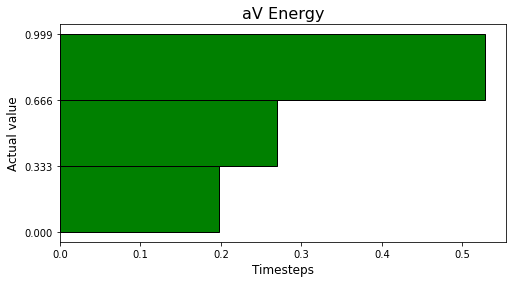

In [62]:
plt.figure(figsize=(8, 4))
normal = np.ones_like(df_energy_aV)/float(len(df_energy_aV))
plt.hist(df_energy_aV, weights=normal, bins=[0,0.3333,0.666,0.999], color = "green", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('aV Energy', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [63]:
df_water_aV = df_allo['aVWater']
df_water_dV = df_allo['dVWater']
print(round(df_water_aV.mean(),3), round(df_water_aV.std(),3), round(df_water_aV.min(),3))
stat_normal, p_normal = sci.normaltest(df_water_aV) 
print("Normality test p value = " + str(p_normal))

0.697 0.253 0.1
Normality test p value = 0.0


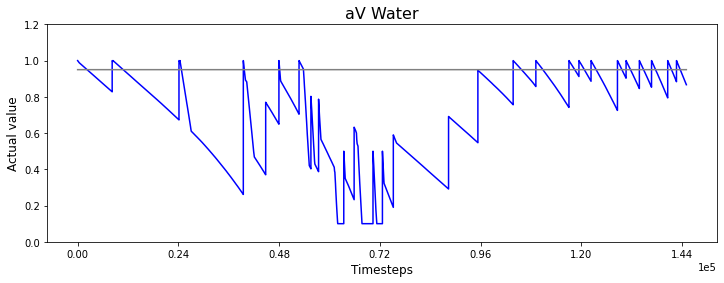

In [64]:
water_steps = round(len(df_water_aV)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_water_aV,'blue')
plt.plot(df_water_dV,'grey')
plt.xticks(np.arange(0, len(df_water_aV), step=water_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.3, step=0.2))
plt.title('aV Water', fontsize=16)
plt.ylabel('Actual value', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

In [65]:
top_bin_w=[]
mid_bin_w=[]
bot_bin_w=[]

for i in range(len(df_water_aV)):
    if df_water_aV[i] <= 1/3:
        bot_bin_w.append(df_water_aV[i])
    if df_water_aV[i] > 1/3 and df_water_aV[i] < 2/3:
        mid_bin_w.append(df_water_aV[i])
    if df_water_aV[i] >= 2/3:
        top_bin_w.append(df_water_aV[i])
        
if len(bot_bin_w) > 0:        
    mean_bot_bin_w = round(sum(bot_bin_w)/len(bot_bin_w),3)
    print("Bot_bin mean value = " + str(mean_bot_bin_w))
if len(mid_bin_w) > 0:  
    mean_mid_bin_w = round(sum(mid_bin_w)/len(mid_bin_w),3)
    print("Mid_bin mean value = " + str(mean_mid_bin_w))
if len(top_bin_w) > 0:  
    mean_top_bin_w = round(sum(top_bin_w)/len(top_bin_w),3)
    print("Top_bin mean value = " + str(mean_top_bin_w))

Bot_bin mean value = 0.213
Mid_bin mean value = 0.49
Top_bin mean value = 0.874


In [66]:
bot_bin_array_w = np.array(bot_bin_w)
mid_bin_array_w = np.array(mid_bin_w)
top_bin_array_w = np.array(top_bin_w)

if p_normal < 0.05:
    bot_mid_stat, bot_mid_p = sci.mannwhitneyu(bot_bin_array_w, mid_bin_array_w)
    print("Mann whitney U pvalue for bot/mid bins = " + str(bot_mid_p))
    top_mid_stat, top_mid_p = sci.mannwhitneyu(top_bin_array_w, mid_bin_array_w)
    print("Mann whitney U pvalue for top/mid bins = " + str(top_mid_p))
else:
    bot_mid_stat, bot_mid_p = sci.ttest_ind(bot_bin_array_w, mid_bin_array_w)
    print("T-test pvalue for bot/mid bins = " + str(bot_mid_p))
    top_mid_stat, top_mid_p = sci.ttest_ind(top_bin_array_w, mid_bin_array_w)
    print("T-test pvalue for top/mid bins = " + str(top_mid_p))
    
print("")
print(sci.levene(bot_bin_array_w, mid_bin_array_w))
print(sci.levene(top_bin_array_w, mid_bin_array_w))

Mann whitney U pvalue for bot/mid bins = 0.0
Mann whitney U pvalue for top/mid bins = 0.0

LeveneResult(statistic=271.17330669753943, pvalue=8.767382332993703e-61)
LeveneResult(statistic=353.74529818957205, pvalue=8.256023563225164e-79)


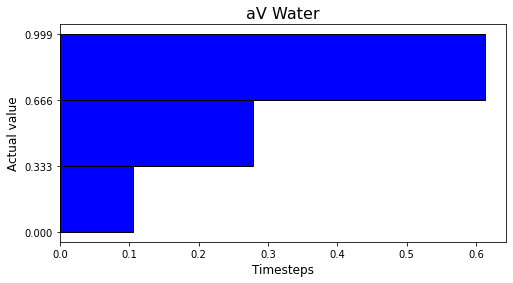

In [67]:
plt.figure(figsize=(8, 4))
normal = np.ones_like(df_water_aV)/float(len(df_water_aV))
plt.hist(df_water_aV, weights=normal, bins=[0,0.3333,0.666,0.999], color = "blue", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('aV Water', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [68]:
df_temp_aV = df_allo['aVTemp']
df_temp_dV = df_allo['dVTemp'] 
if df_temp_dV[0] < 0.9:
    df_temp_dV = df_temp_dV + 0.1
print(round(df_temp_aV.mean(), 3), round(df_temp_aV.std(), 3))
stat_normal, p_normal = sci.normaltest(df_temp_aV) 
print("Normality test p value = " + str(p_normal))

0.608 0.342
Normality test p value = 0.0


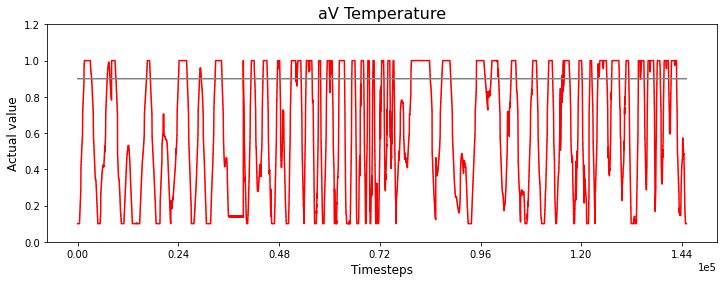

In [69]:
temp_steps = round(len(df_temp_aV)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_temp_aV,'red')
plt.plot(df_temp_dV,'grey')
plt.xticks(np.arange(0, len(df_temp_aV), step=temp_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.3, step=0.2))
plt.title('aV Temperature', fontsize=16)
plt.ylabel('Actual value', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

In [70]:
df_temp_aV_mapped = []
df_temp_dV_mapped = []
for i in range(len(df_temp_aV)):
    df_temp_aV_mapped.append(valMap(df_temp_aV[i], 0, 1, 50, 27.5))
for j in range(len(df_temp_dV)):
     df_temp_dV_mapped.append(valMap(df_temp_dV[i], 0, 1, 50, 27.5))
df_temp_aV_mapped = np.array(df_temp_aV_mapped)
print(round(df_temp_aV_mapped.mean(), 1))

36.3


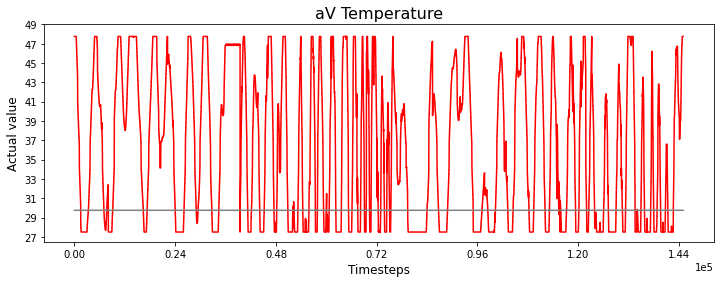

In [71]:
temp_steps = round(len(df_temp_aV_mapped)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_temp_aV_mapped,'red')
plt.plot(df_temp_dV_mapped,'grey')
plt.xticks(np.arange(0, len(df_temp_aV_mapped), step=temp_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(27, 51, step=2))
plt.title('aV Temperature', fontsize=16)
plt.ylabel('Actual value', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

In [72]:
top_bin_t=[]
mid_bin_t=[]
bot_bin_t=[]

for i in range(len(df_temp_aV)):
    if df_temp_aV[i] <= 1/3:
        bot_bin_t.append(df_temp_aV[i])
    if df_temp_aV[i] > 1/3 and df_temp_aV[i] < 2/3:
        mid_bin_t.append(df_temp_aV[i])
    if df_temp_aV[i] >= 2/3:
        top_bin_t.append(df_temp_aV[i])
        
if len(bot_bin_t) > 0:        
    mean_bot_bin_t = round(sum(bot_bin_t)/len(bot_bin_t),3)
    print("Bot_bin mean value = " + str(mean_bot_bin_t))
if len(mid_bin_t) > 0:  
    mean_mid_bin_t = round(sum(mid_bin_t)/len(mid_bin_t),3)
    print("Mid_bin mean value = " + str(mean_mid_bin_t))
if len(top_bin_t) > 0:  
    mean_top_bin_t = round(sum(top_bin_t)/len(top_bin_t),3)
    print("Top_bin mean value = " + str(mean_top_bin_t))

Bot_bin mean value = 0.175
Mid_bin mean value = 0.462
Top_bin mean value = 0.931


In [73]:
bot_bin_array_t = np.array(bot_bin_t)
mid_bin_array_t = np.array(mid_bin_t)
top_bin_array_t = np.array(top_bin_t)

if p_normal < 0.05:
    bot_mid_stat, bot_mid_p = sci.mannwhitneyu(bot_bin_array_t, mid_bin_array_t)
    print("Mann whitney U pvalue for bot/mid bins = " + str(bot_mid_p))
    top_mid_stat, top_mid_p = sci.mannwhitneyu(top_bin_array_t, mid_bin_array_t)
    print("Mann whitney U pvalue for top/mid bins = " + str(top_mid_p))
else:
    bot_mid_stat, bot_mid_p = sci.ttest_ind(bot_bin_array_t, mid_bin_array_t)
    print("T-test pvalue for bot/mid bins = " + str(bot_mid_p))
    top_mid_stat, top_mid_p = sci.ttest_ind(top_bin_array_t, mid_bin_array_t)
    print("T-test pvalue for top/mid bins = " + str(top_mid_p))
    
print("")
print(sci.levene(bot_bin_array_t, mid_bin_array_t))
print(sci.levene(top_bin_array_t, mid_bin_array_t))

Mann whitney U pvalue for bot/mid bins = 0.0
Mann whitney U pvalue for top/mid bins = 0.0

LeveneResult(statistic=48.646174249580305, pvalue=3.091171096416482e-12)
LeveneResult(statistic=163.06472304490757, pvalue=2.584562749811569e-37)


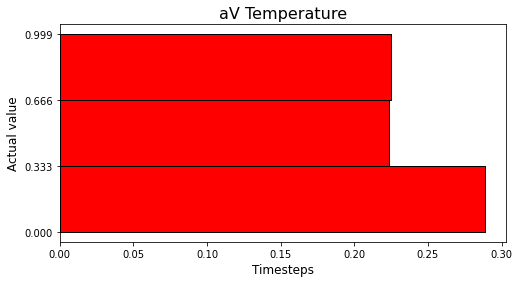

In [74]:
plt.figure(figsize=(8, 4))
normal = np.ones_like(df_temp_aV)/float(len(df_temp_aV))
plt.hist(df_temp_aV, weights=normal, bins=[0,0.3333,0.666,0.999], color = "red", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('aV Temperature', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

#### Intensity ∣aV - dV∣

In [75]:
df_hunger_U = df_allo['UHunger']
df_hunger_filtered = butter_lowpass_filter(df_hunger_U, 2, 50, 3)

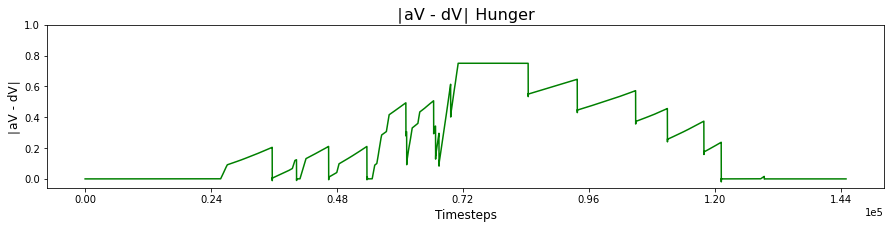

In [76]:
hunger_steps = round(len(df_hunger_U)/6,-3)
plt.figure(figsize=(15, 3))
plt.plot(df_hunger_filtered,'green')
plt.xticks(np.arange(0, len(df_hunger_U), step=hunger_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.1, step=0.2))
plt.title('∣aV - dV∣ Hunger', fontsize=16)
plt.ylabel('∣aV - dV∣', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

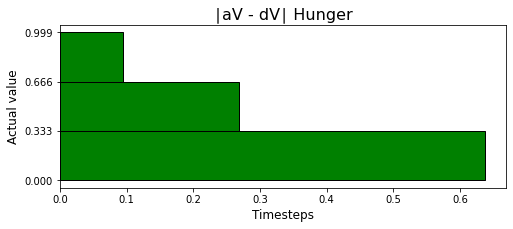

In [77]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_hunger_U)/float(len(df_hunger_U))
plt.hist(df_hunger_U, weights=normal, bins=[0,0.3333,0.666,0.999], color = "green", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('∣aV - dV∣ Hunger', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [78]:
df_thirst_U = df_allo['UThirst']
df_thirst_filtered = butter_lowpass_filter(df_thirst_U, 2, 50, 3)

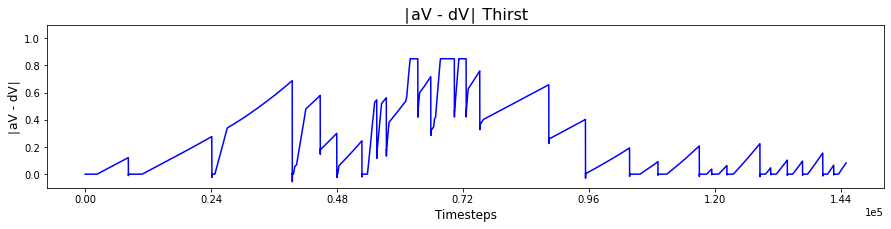

In [79]:
thirst_steps = round(len(df_thirst_U)/6,-3)
plt.figure(figsize=(15, 3))
plt.plot(df_thirst_filtered,'blue')
plt.xticks(np.arange(0, len(df_thirst_U), step=thirst_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.1, step=0.2))
plt.title('∣aV - dV∣ Thirst', fontsize=16)
plt.ylabel('∣aV - dV∣', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.ylim(-0.1,1.1)
plt.show()

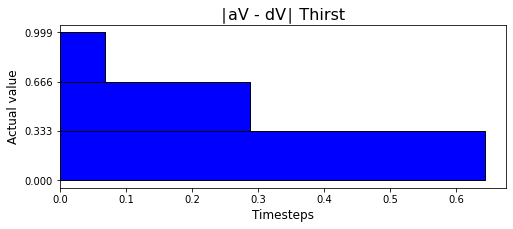

In [80]:
plt.figure(figsize=(8, 3))
normal = np.ones_like(df_thirst_U)/float(len(df_thirst_U))
plt.hist(df_thirst_U, weights=normal, bins=[0,0.3333,0.666,0.999], color = "blue", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('∣aV - dV∣ Thirst', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

In [81]:
df_temp_U = df_allo['UTemp']
df_temp_filtered = butter_lowpass_filter(df_temp_U, 2, 50, 3)

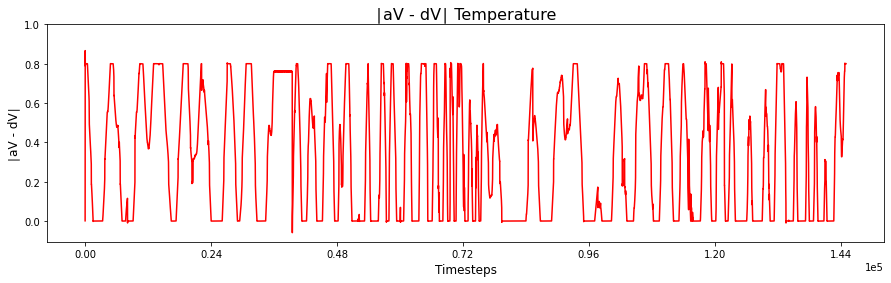

In [82]:
temp_steps = round(len(df_temp_U)/6,-3)
plt.figure(figsize=(15, 4))
plt.plot(df_temp_filtered,'red')
plt.xticks(np.arange(0, len(df_temp_U), step=temp_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.1, step=0.2))
plt.title('∣aV - dV∣ Temperature', fontsize=16)
plt.ylabel('∣aV - dV∣', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

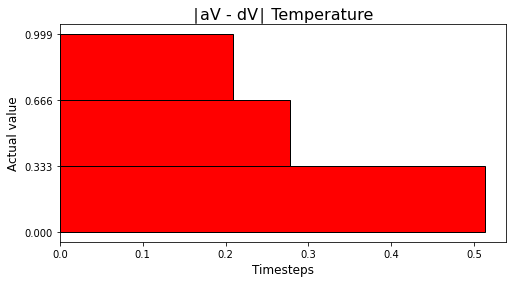

In [83]:
plt.figure(figsize=(8, 4))
normal = np.ones_like(df_temp_U)/float(len(df_temp_U))
plt.hist(df_temp_U, weights=normal, bins=[0,0.3333,0.666,0.999], color = "red", edgecolor='black', orientation='horizontal')

index1 = 1/6
index2 = 29/60
index3 = 31/60
index4 = 5/6

plt.yticks(np.arange(0, 1, step=0.333))
plt.title('∣aV - dV∣ Temperature', fontsize=16)
plt.xlabel('Timesteps', fontsize=12)
plt.ylabel('Actual value', fontsize=12)
plt.show()

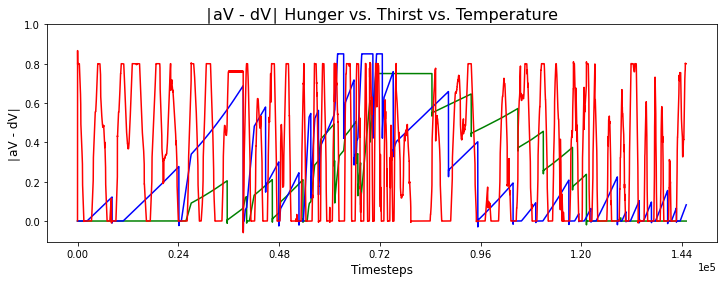

In [84]:
plt.figure(figsize=(12, 4))
plt.plot(df_hunger_filtered,'green')
plt.plot(df_thirst_filtered,'blue')
plt.plot(df_temp_filtered,'red')
plt.xticks(np.arange(0, len(df_thirst_U), step=thirst_steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.1, step=0.2))
plt.title('∣aV - dV∣ Hunger vs. Thirst vs. Temperature', fontsize=16)
plt.ylabel('∣aV - dV∣', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

### Allostasis

#### Allostatic load AL

In [85]:
df_hunger_AL = df_allo['ALHunger']
print(round(df_hunger_AL.mean(), 4))
df_thirst_AL = df_allo['ALThirst']
print(round(df_thirst_AL.mean(), 4))
df_temp_AL = df_allo['ALTemp']
print(round(df_temp_AL.mean(), 4))

0.2841
0.2351
0.065


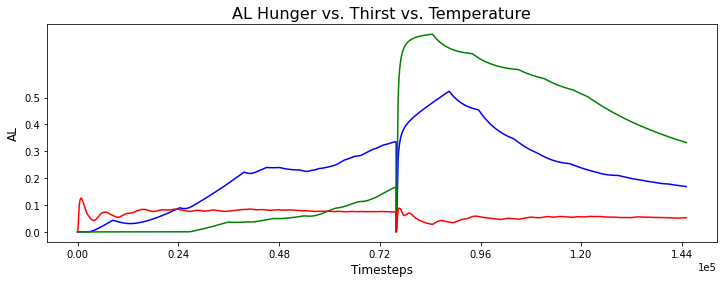

In [86]:
steps = round(len(df_thirst_AL)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_thirst_AL,'blue')
plt.plot(df_hunger_AL,'green')
plt.plot(df_temp_AL,'red')
plt.xticks(np.arange(0, len(df_thirst_AL), step=steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 0.6, step=0.1))
plt.title('AL Hunger vs. Thirst vs. Temperature', fontsize=16)
plt.ylabel('AL', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

#### Resource detected n

In [87]:
df_hunger_n = df_allo['NFood']
df_thirst_n = df_allo['NWater']

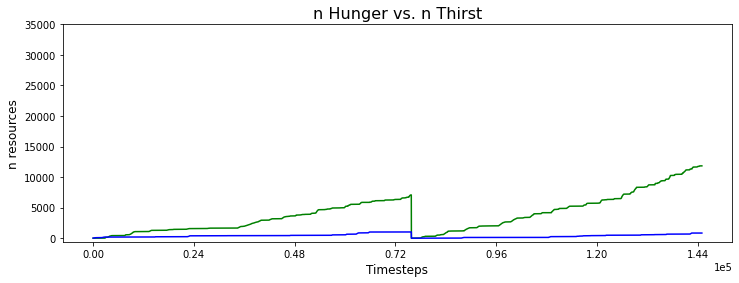

In [88]:
steps = round(len(df_hunger_n)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_hunger_n,'green')
plt.plot(df_thirst_n,'blue')
plt.xticks(np.arange(0, len(df_hunger_n), step=steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 40000, step=5000))
plt.title('n Hunger vs. n Thirst', fontsize=16)
plt.ylabel('n resources', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

#### Weighting factor k

In [89]:
df_hunger_K = df_allo['kHunger'] 
df_thirst_K = df_allo['kThirst'] 
df_temp_K = df_allo['kTemp'] 

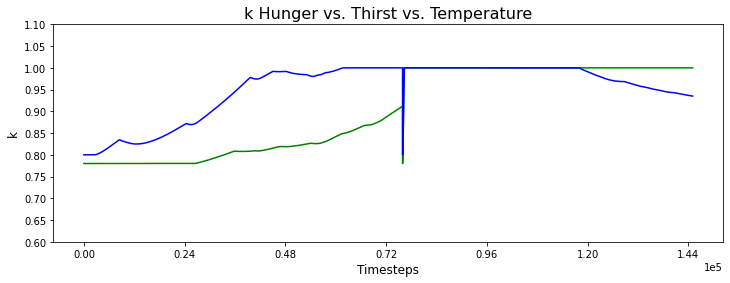

In [90]:
steps = round(len(df_hunger_K)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_hunger_K,'green')
plt.plot(df_thirst_K,'blue')
#plt.plot(df_temp_K,'red')
plt.xticks(np.arange(0, len(df_hunger_K), step=steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(0, 1.3, step=0.05))
plt.title('k Hunger vs. Thirst vs. Temperature', fontsize=16)
plt.ylabel('k', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.ylim(0.6, 1.1)
plt.show()

#### Force f = 1 + ∣aV - dV∣ * k

In [91]:
df_hunger_D = df_allo['DHunger'] + 1
print(round(df_hunger_D.mean(), 4))
df_thirst_D = df_allo['DThirst'] + 1
print(round(df_thirst_D.mean(), 4))
df_temp_D = df_allo['DTemp'] + 1
print(round(df_temp_D.mean(), 4))

1.2344
1.2497
1.2924


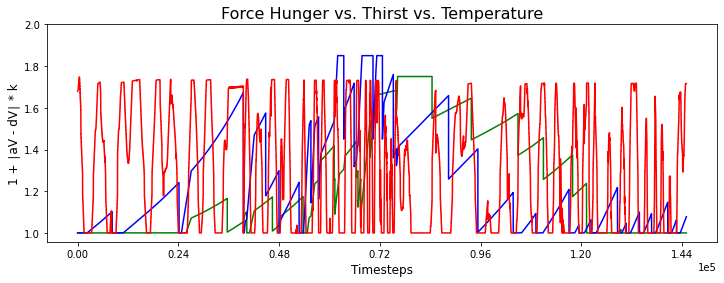

In [92]:
steps = round(len(df_hunger_D)/6,-3)
plt.figure(figsize=(12, 4))
plt.plot(df_hunger_D,'green')
plt.plot(df_thirst_D,'blue')
plt.plot(df_temp_D,'red')
plt.xticks(np.arange(0, len(df_hunger_D), step=steps))
plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
plt.yticks(np.arange(1, 2.1, step=0.2))
plt.title('Force Hunger vs. Thirst vs. Temperature', fontsize=16)
plt.ylabel('1 + ∣aV - dV∣ * k', fontsize=12)
plt.xlabel('Timesteps', fontsize=12)
plt.show()

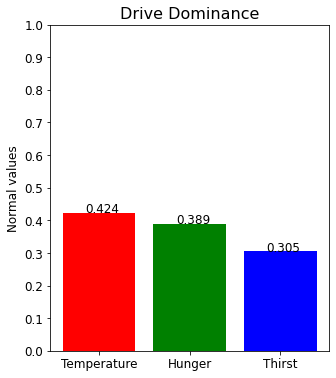

In [93]:
temp_count = 0
food_count = 0
water_count = 0

for i in range(len(df_temp_D)):
    if df_temp_D[i] > df_thirst_D[i] and df_temp_D[i] > df_hunger_D[i] and df_temp_D[i] > 0.3:
        temp_count += 1
    if df_hunger_D[i] > df_temp_D[i] and df_hunger_D[i] > df_temp_D[i]:
        food_count += 1
    if df_thirst_D[i] > df_temp_D[i] and df_thirst_D[i] > df_hunger_D[i]:
        water_count += 1
        
norm_t = temp_count/len(df_temp_D)
norm_f = food_count/len(df_hunger_D)
norm_w = water_count/len(df_thirst_D)

objects = ('Temperature', 'Hunger', 'Thirst')
y_pos = np.arange(len(objects))
values = [round(norm_t , 3), round(norm_f, 3), round(norm_w, 3)]

plt.figure(figsize=(5, 6))
plt.bar(y_pos, values, align='center', color=['red', 'green', 'blue'])
plt.xticks(y_pos, objects, fontsize=12)
plt.ylabel('Normal values', fontsize=12)
plt.yticks(np.arange(0, 1.1, step=0.1), fontsize=12)
plt.title('Drive Dominance', fontsize=16)

for index, value in enumerate(values):
    plt.text(index-0.15, value, str(value), fontsize=12)
plt.show()

In [94]:
hunger_corr = pd.concat([df_hunger_n, df_hunger_U, df_hunger_AL, df_hunger_K, df_hunger_D], axis=1).corr()
print(hunger_corr)

             NFood   UHunger  ALHunger   kHunger   DHunger
NFood     1.000000 -0.194039  0.131295  0.447252 -0.213735
UHunger  -0.194039  1.000000  0.567265  0.442597  0.996188
ALHunger  0.131295  0.567265  1.000000  0.940844  0.621090
kHunger   0.447252  0.442597  0.940844  1.000000  0.484659
DHunger  -0.213735  0.996188  0.621090  0.484659  1.000000


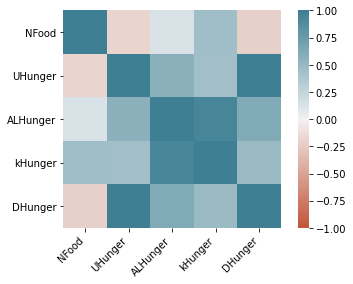

In [95]:
ax = sns.heatmap(
    hunger_corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=500),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

In [96]:
thirst_corr = pd.concat([df_thirst_n, df_thirst_U, df_thirst_AL, df_thirst_K, df_thirst_D], axis=1).corr()
print(thirst_corr)

            NWater   UThirst  ALThirst   kThirst   DThirst
NWater    1.000000  0.299591 -0.149513  0.192319  0.304587
UThirst   0.299591  1.000000  0.365798  0.335123  0.998829
ALThirst -0.149513  0.365798  1.000000  0.851300  0.392665
kThirst   0.192319  0.335123  0.851300  1.000000  0.362527
DThirst   0.304587  0.998829  0.392665  0.362527  1.000000


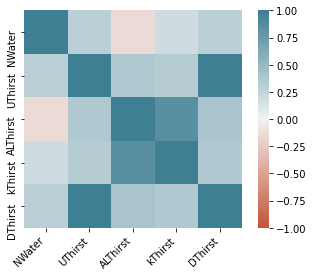

In [97]:
ax = sns.heatmap(
    thirst_corr, 
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=500),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);